#### Data Transformation -> Feature engineering 
Create a new feature/column based on some values already existing on our data. 
We may need to do this when we 'feel' the need of that feature, but it does not exist in our
original data ####

In [1]:
import pandas as pd
df = pd.read_csv('raw_data.csv')

In [2]:
# Using .apply() for FE.

df2 = df.copy()
# Calculate mean income to fill NaN values in income column.
meanIncome = df2['income'].mean()
print(meanIncome)
df2['income'] = df2['income'].fillna(meanIncome).copy()
# Feature engineering the column - Tax Percentage
# .apply() is a Higher-order-function which takes another function name, or function defn. as its parameter.
df2['tax percentage'] = df2['income'].apply(lambda incm: "20%" if incm >= 62_000 else "10%")
df2['tax amount'] = df2['income'].apply(lambda incm: 0.2*incm if incm>=62_000 else 0.1*incm)
df2


76874.5


,id,name,age,country,gender,income,tax percentage,tax amount
0,1,Rahul Deshmukh,29.0,India,Male,55000.0,10%,5500.0
1,1,Rahul Deshmukh,29.0,India,Male,55000.0,10%,5500.0
2,2,Ananya Iyer,NaN,India,Female,62000.0,20%,12400.0
3,3,Alex Johnson,NaN,USA,Unknown,47000.0,10%,4700.0
4,4,Maria Garcia,34.0,Spain,Female,76874.5,20%,15374.9
5,5,Li Wei,27.0,China,Male,51000.0,10%,5100.0
6,6,NaN,45.0,India,Female,73000.0,20%,14600.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0,20%,13600.0
8,8,Rachel Lee,29.0,USA,Female,62000.0,20%,12400.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0,10%,4500.0


In [3]:
# Using .map() for FE
gender_map = {
    'Male':'M',
    'Female':'F',
    'Unknown':'U_K'
}
df2['gender'] = df2['gender'].map(gender_map).copy()
df2

,id,name,age,country,gender,income,tax percentage,tax amount
0,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0
1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0
2,2,Ananya Iyer,NaN,India,F,62000.0,20%,12400.0
3,3,Alex Johnson,NaN,USA,U_K,47000.0,10%,4700.0
4,4,Maria Garcia,34.0,Spain,F,76874.5,20%,15374.9
5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0
6,6,NaN,45.0,India,F,73000.0,20%,14600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,13600.0
8,8,Rachel Lee,29.0,USA,F,62000.0,20%,12400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0


In [4]:
# Using .assing() and Square Braces notation to manually assign values to a manually made column

# .assign()
df2 = df2.assign(new_income = df2['income'] + df2['tax amount']).copy()
# The 1st parameter of .assing() can't contain Spaces...same rules as python variables.

# Better to go with the below Square Bracket notation if you must have spaces, Descriptive on its own, no copying bla bla needed.
df2['new income'] = df2['income'] + df2['tax amount']

df2

,id,name,age,country,gender,income,tax percentage,tax amount,new_income,new income
0,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
2,2,Ananya Iyer,NaN,India,F,62000.0,20%,12400.0,74400.0,74400.0
3,3,Alex Johnson,NaN,USA,U_K,47000.0,10%,4700.0,51700.0,51700.0
4,4,Maria Garcia,34.0,Spain,F,76874.5,20%,15374.9,92249.4,92249.4
5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
6,6,NaN,45.0,India,F,73000.0,20%,14600.0,87600.0,87600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,13600.0,81600.0,81600.0
8,8,Rachel Lee,29.0,USA,F,62000.0,20%,12400.0,74400.0,74400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0


In [5]:
# .replace(oldValues, newValues)
df2['country'] = df2['country'].replace("USA", "United States").copy()
df2

,id,name,age,country,gender,income,tax percentage,tax amount,new_income,new income
0,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
2,2,Ananya Iyer,NaN,India,F,62000.0,20%,12400.0,74400.0,74400.0
3,3,Alex Johnson,NaN,United States,U_K,47000.0,10%,4700.0,51700.0,51700.0
4,4,Maria Garcia,34.0,Spain,F,76874.5,20%,15374.9,92249.4,92249.4
5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
6,6,NaN,45.0,India,F,73000.0,20%,14600.0,87600.0,87600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,13600.0,81600.0,81600.0
8,8,Rachel Lee,29.0,United States,F,62000.0,20%,12400.0,74400.0,74400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0


#### Data Transformation -> Other operations

In [6]:
# Rename all columns manually.... 
df2.info
df2.columns = ["ID", "Name", "Age", "Country", "Gender", "Income", "Tax", "Tax Amount", "New Income from .assign()", "New Income from Braces Notation"] # Lengths must match !!!
# Rename some column labels only
df2 = df2.rename(columns={"Income":"Salary"}).copy()
# Rename some row labels only
df2 = df2.rename(index={0:"Zeroth Row"}).copy()
df2

,ID,Name,Age,Country,Gender,Salary,Tax,Tax Amount,New Income from .assign(),New Income from Braces Notation
Zeroth Row,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
2,2,Ananya Iyer,NaN,India,F,62000.0,20%,12400.0,74400.0,74400.0
3,3,Alex Johnson,NaN,United States,U_K,47000.0,10%,4700.0,51700.0,51700.0
4,4,Maria Garcia,34.0,Spain,F,76874.5,20%,15374.9,92249.4,92249.4
5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
6,6,NaN,45.0,India,F,73000.0,20%,14600.0,87600.0,87600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,13600.0,81600.0,81600.0
8,8,Rachel Lee,29.0,United States,F,62000.0,20%,12400.0,74400.0,74400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0


In [7]:
# Sort values
df2.sort_values("Salary") # Does not change in place !
df2 = df2.sort_values("Salary").copy() # Sort with respect to Salary values
sorted_data = df2.sort_values(['Salary', 'Age']).copy() # Sort with more than 1 col values-> use Age to sort if Salary of 2 rows are same
sorted_data

,ID,Name,Age,Country,Gender,Salary,Tax,Tax Amount,New Income from .assign(),New Income from Braces Notation
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0
3,3,Alex Johnson,NaN,United States,U_K,47000.0,10%,4700.0,51700.0,51700.0
5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
15,14,Siddharth Rao,26.0,India,NaN,52000.0,10%,5200.0,57200.0,57200.0
Zeroth Row,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
10,10,Emily Davis,31.0,United States,M,58000.0,10%,5800.0,63800.0,63800.0
20,19,Chloe Dubois,28.0,France,F,59000.0,10%,5900.0,64900.0,64900.0
18,17,NaN,29.0,India,M,61000.0,10%,6100.0,67100.0,67100.0
8,8,Rachel Lee,29.0,United States,F,62000.0,20%,12400.0,74400.0,74400.0


In [8]:
# Sort indices -> By default Row Labels are Row indices, so better would be to say Sort using Row Labels. (indices word might be confusing here, indices don't mean True Positions in which they appear, they are actually the Row Labels)
sorted_data = sorted_data.rename(index={"Zeroth Row":0}).copy()
sorted_data1 = sorted_data.sort_index().copy() # 😢 Totally ignores previously done sort values !!!!

# Reset Index to 🔥🔥 persist column order done previously, but reset the indices -> Maintains Row Labels and also maintains previously done sorting according to Column values #🔥🔥
sorted_data2 = sorted_data.reset_index() # Creates a new column named "index" to hold original Index/Label values before resetting index.
# 🩵 Use drop=True, to remove that "index" column
sorted_data3 = sorted_data.reset_index(drop=True)

In [9]:
sorted_data1

,ID,Name,Age,Country,Gender,Salary,Tax,Tax Amount,New Income from .assign(),New Income from Braces Notation
0,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
2,2,Ananya Iyer,NaN,India,F,62000.0,20%,12400.0,74400.0,74400.0
3,3,Alex Johnson,NaN,United States,U_K,47000.0,10%,4700.0,51700.0,51700.0
4,4,Maria Garcia,34.0,Spain,F,76874.5,20%,15374.9,92249.4,92249.4
5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
6,6,NaN,45.0,India,F,73000.0,20%,14600.0,87600.0,87600.0
7,7,Ahmed Khan,38.0,NaN,M,68000.0,20%,13600.0,81600.0,81600.0
8,8,Rachel Lee,29.0,United States,F,62000.0,20%,12400.0,74400.0,74400.0
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0


In [10]:
sorted_data2

,index,ID,Name,Age,Country,Gender,Salary,Tax,Tax Amount,New Income from .assign(),New Income from Braces Notation
0,9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0
1,3,3,Alex Johnson,NaN,United States,U_K,47000.0,10%,4700.0,51700.0,51700.0
2,5,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
3,15,14,Siddharth Rao,26.0,India,NaN,52000.0,10%,5200.0,57200.0,57200.0
4,0,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
5,1,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
6,10,10,Emily Davis,31.0,United States,M,58000.0,10%,5800.0,63800.0,63800.0
7,20,19,Chloe Dubois,28.0,France,F,59000.0,10%,5900.0,64900.0,64900.0
8,18,17,NaN,29.0,India,M,61000.0,10%,6100.0,67100.0,67100.0
9,8,8,Rachel Lee,29.0,United States,F,62000.0,20%,12400.0,74400.0,74400.0


In [11]:
sorted_data3

,ID,Name,Age,Country,Gender,Salary,Tax,Tax Amount,New Income from .assign(),New Income from Braces Notation
0,9,Carlos Ruiz,NaN,Mexico,M,45000.0,10%,4500.0,49500.0,49500.0
1,3,Alex Johnson,NaN,United States,U_K,47000.0,10%,4700.0,51700.0,51700.0
2,5,Li Wei,27.0,China,M,51000.0,10%,5100.0,56100.0,56100.0
3,14,Siddharth Rao,26.0,India,NaN,52000.0,10%,5200.0,57200.0,57200.0
4,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
5,1,Rahul Deshmukh,29.0,India,M,55000.0,10%,5500.0,60500.0,60500.0
6,10,Emily Davis,31.0,United States,M,58000.0,10%,5800.0,63800.0,63800.0
7,19,Chloe Dubois,28.0,France,F,59000.0,10%,5900.0,64900.0,64900.0
8,17,NaN,29.0,India,M,61000.0,10%,6100.0,67100.0,67100.0
9,8,Rachel Lee,29.0,United States,F,62000.0,20%,12400.0,74400.0,74400.0


In [12]:
# Ranking -> Create a rank column based on some col values
d3 = df.copy()
d3['Income Ranking'] = d3['income'].rank(ascending=False, method="dense")
d3 = d3.sort_values(['income', 'age'], ascending=False).copy()
d3 = d3.reset_index(drop=True)
d3

,id,name,age,country,gender,income,Income Ranking
0,21,Sahra Malik,37.0,Egypt,Female,238490.0,1.0
1,18,Arjun Malhotra,35.0,India,Male,120000.0,2.0
2,11,Amit Patel,30.0,India,Male,95000.0,3.0
3,11,Amit Patel,30.0,India,Male,95000.0,3.0
4,20,Priya Rai,41.0,India,Female,88000.0,4.0
5,13,Hans Schmidt,42.0,Germany,Male,82000.0,5.0
6,6,NaN,45.0,India,Female,73000.0,6.0
7,15,Yuki Tanaka,NaN,Japan,Female,71000.0,7.0
8,7,Ahmed Khan,38.0,NaN,Male,68000.0,8.0
9,8,Rachel Lee,29.0,USA,Female,62000.0,9.0


In [13]:
# Rearranging columns --> 🍀🍀 PERFECT ORDER 🍀🍀
# 1. Create the Rank
d4 = df.copy()
d4['Income Ranking'] = d4['income'].rank(ascending=False, method="dense")

# 2. Sort the data
d4 = d4.sort_values(['income', 'age'], ascending=False)

# 3. Reset index to clean up the 'jumble'
d4 = d4.reset_index(drop=True)

# 4. Rearrange (This ONLY changes the order of display)
# ⚠️ THIS IS NOT RENAMING !!! AS WE MAY GET CONFUSED FROM EARLIER RENAMINGS, WE USED A COPY FROM THE ORIGINAL DF INSTEAD.
cols_in_order = ["id", "name", "age", "country", "income", "Income Ranking", "gender"]
d4 = d4[cols_in_order].copy()

d4

,id,name,age,country,income,Income Ranking,gender
0,21,Sahra Malik,37.0,Egypt,238490.0,1.0,Female
1,18,Arjun Malhotra,35.0,India,120000.0,2.0,Male
2,11,Amit Patel,30.0,India,95000.0,3.0,Male
3,11,Amit Patel,30.0,India,95000.0,3.0,Male
4,20,Priya Rai,41.0,India,88000.0,4.0,Female
5,13,Hans Schmidt,42.0,Germany,82000.0,5.0,Male
6,6,NaN,45.0,India,73000.0,6.0,Female
7,15,Yuki Tanaka,NaN,Japan,71000.0,7.0,Female
8,7,Ahmed Khan,38.0,NaN,68000.0,8.0,Male
9,8,Rachel Lee,29.0,USA,62000.0,9.0,Female


In [14]:
#...Task -> Shift ID column to end, # Using List-Comprehension !!
emp = pd.read_csv('raw_data.csv')
# print(emp.columns)
# List comprehension below...
new_cols_order = [col_name for col_name in emp.columns if col_name!='id'] # Exclude ID col
new_cols_order.append(emp.columns[0]) # Append back ID col assuming that it is the 0-th Col Label
# print(new_cols_order)
emp = emp[new_cols_order].copy()
emp

,name,age,country,gender,income,id
0,Rahul Deshmukh,29.0,India,Male,55000.0,1
1,Rahul Deshmukh,29.0,India,Male,55000.0,1
2,Ananya Iyer,NaN,India,Female,62000.0,2
3,Alex Johnson,NaN,USA,Unknown,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Ruiz,NaN,Mexico,Male,45000.0,9


In [15]:
# Processing data and writing cleaned data to csv files
emp = pd.read_csv('raw_data.csv')
# Removing Duplicates
emp = emp.drop_duplicates().copy()
# Filling null values to according value
mean_age = emp['age'].mean()
mean_salary = emp['income'].mean()
unknown_name = "ANONYMOUS_USER"
unknown_country = "UNKNOWN_COUNTRY"
emp['income'] = emp['income'].fillna(mean_salary).copy()
emp['age'] = emp['age'].fillna(mean_age).copy()
emp['country'] = emp['country'].fillna(unknown_country).copy()
emp['name'] = emp['name'].fillna(unknown_name).copy()
#..only remaining col with NaN values are gender, so directly use .fillna()
emp = emp.fillna("PREFER NOT TO SAY").copy()
# Sorting by income
emp = emp.sort_values('income', ascending=False).copy()
# Resetting indices and not preserving original indices
emp = emp.reset_index(drop=True)

# Writing to new CSV file 
emp.to_csv("cleaned_data.csv")

In [16]:
#...Group by and Aggregation
emp.groupby('country')['income'].mean() # Create groups for different countries and calculate mean across the groups of the 'income' column

country
China               51000.000000
Egypt              157786.388889
France              59000.000000
Germany             82000.000000
India               75898.086420
Japan               71000.000000
Mexico              45000.000000
Spain               77082.777778
UNKNOWN_COUNTRY     68000.000000
USA                 55666.666667
Name: income, dtype: float64

In [17]:
#..same for the age, but instead of mean, we calculate the max ages for different countries
print(emp.groupby('country')['age'].max())

country
China              27.000
Egypt              37.000
France             28.000
Germany            42.000
India              45.000
Japan              33.375
Mexico             33.375
Spain              34.000
UNKNOWN_COUNTRY    38.000
USA                33.375
Name: age, dtype: float64


In [18]:
#..Multi-col grouping like - USA-Male, USA-Female, India-Male, India-Female...and so on
emp.groupby(['country', 'gender'])['age'].max()

country          gender           
China            Male                 27.000
Egypt            Female               37.000
France           Female               28.000
Germany          Male                 42.000
India            Female               45.000
                 Male                 35.000
                 PREFER NOT TO SAY    26.000
Japan            Female               33.375
Mexico           Male                 33.375
Spain            Female               34.000
UNKNOWN_COUNTRY  Male                 38.000
USA              Female               29.000
                 Male                 31.000
                 Unknown              33.375
Name: age, dtype: float64

In [19]:
#... Multiple aggregation functions using .agg()
emp.groupby(['country'])['income'].agg(['min', 'max'])

,min,max
country,,
China,51000.000000,51000.000000
Egypt,77082.777778,238490.000000
France,59000.000000,59000.000000
Germany,82000.000000,82000.000000
India,52000.000000,120000.000000
Japan,71000.000000,71000.000000
Mexico,45000.000000,45000.000000
Spain,77082.777778,77082.777778
UNKNOWN_COUNTRY,68000.000000,68000.000000


In [ ]:
#.. Applying different agg functions on different columns
emp.groupby(['country']).agg({
    'income':'mean',
    'age': ['min', 'max'], # ⚠️ Mind that List passing is necessary because in Python Dictonaries the keys are unique ! So if we seperately write 'age':"max", it will overwrite the previous 'age':'min'.
})

income     age        
                          mean     min     max
country                                       
China             51000.000000  27.000  27.000
Egypt            157786.388889  33.000  37.000
France            59000.000000  28.000  28.000
Germany           82000.000000  42.000  42.000
India             75898.086420  26.000  45.000
Japan             71000.000000  33.375  33.375
Mexico            45000.000000  33.375  33.375
Spain             77082.777778  34.000  34.000
UNKNOWN_COUNTRY   68000.000000  38.000  38.000
USA               55666.666667  29.000  33.375

In [23]:
#.. Applying different agg functions on different columns and Renaming the Columns for better understanding # 🫠 Here duplicate keys can't exist because of Proper/Logical naming of the columns.
emp.groupby(['country']).agg(
    Average_Income = ('income', 'mean'),
    Minimum_Age = ('age', 'min'),
    Maximum_Age = ('age', 'max')
)

,Average_Income,Minimum_Age,Maximum_Age
country,,,
China,51000.000000,27.000,27.000
Egypt,157786.388889,33.000,37.000
France,59000.000000,28.000,28.000
Germany,82000.000000,42.000,42.000
India,75898.086420,26.000,45.000
Japan,71000.000000,33.375,33.375
Mexico,45000.000000,33.375,33.375
Spain,77082.777778,34.000,34.000
UNKNOWN_COUNTRY,68000.000000,38.000,38.000


<Axes: xlabel='age', ylabel='income'>

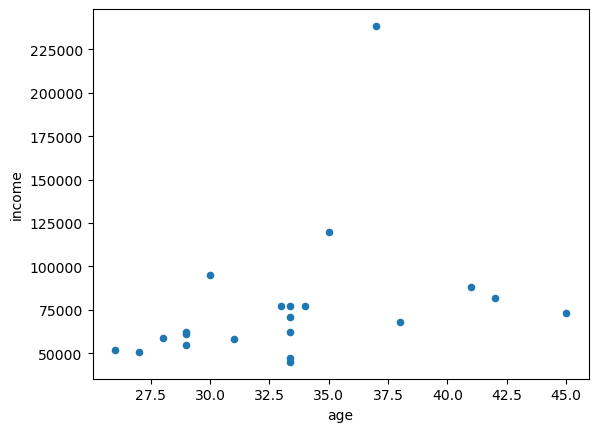

In [35]:
##.. Basic Visualization with Pandas
###.. Observing via a Scatter chart how income changes as a function of time, y = f(x)
emp.plot(kind='scatter', x='age', y='income')